# EDA toàn bộ bộ dữ liệu sản phẩm thuê

Notebook này thực hiện EDA từ đầu đến cuối cho toàn bộ các bảng trong repository: sản phẩm, đơn hàng, giỏ hàng, mapping giữa site cũ - site mới, và các log hành vi lớn (`metrika_hits*`, `metrika_visits*`).

Mục tiêu:
- Kiểm tra cấu trúc dữ liệu và mức độ đầy đủ của từng bảng.
- Phân tích chất lượng dữ liệu: thiếu, trùng, kiểu dữ liệu, khóa nối, giá trị bất thường.
- Phân tích phân phối danh mục, thương hiệu, giá, thời gian, hành vi người dùng.
- Rút ra bài học cho mô hình gợi ý hiện tại.

In [9]:
import ast
import json
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)
pd.set_option('display.max_colwidth', 120)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

ROOT = Path('data')
ROOT.exists()

True

## 1. Danh mục file và kích thước dữ liệu

Trước khi đi vào phân tích chi tiết, cần nhìn nhanh toàn bộ file để biết đâu là bảng nhỏ, đâu là bảng lớn cần xử lý bằng chunk.

In [10]:
files = sorted(ROOT.glob('*.csv'))
overview = []
for path in files:
    size_mb = path.stat().st_size / (1024 * 1024)
    overview.append({'file': path.name, 'size_mb': round(size_mb, 2)})
file_overview = pd.DataFrame(overview).sort_values('size_mb', ascending=False)
file_overview

,file,size_mb
0,metrika_hits.csv,417.19
2,metrika_visits.csv,121.85
5,new_site_products.csv,2.06
8,old_site_orders.csv,1.85
6,old_site_carts.csv,1.68
1,metrika_hits_test.csv,1.63
9,old_site_products.csv,1.63
3,metrika_visits_test.csv,0.51
4,new_site_orders.csv,0.43
7,old_site_new_site_products.csv,0.01


## 2. Hàm tiện ích để profiling dữ liệu lớn

Hai file hành vi lớn là `metrika_hits*.csv` và `metrika_visits*.csv`, nên notebook dùng chunking để đếm số dòng, giá trị thiếu, số lượng unique xấp xỉ, và phân phối các cột quan trọng.

In [11]:
def read_head(path: Path, n: int = 5) -> pd.DataFrame:
    return pd.read_csv(path, nrows=n)

def profile_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in df.columns:
        s = df[col]
        rows.append({
            'column': col,
            'dtype': str(s.dtype),
            'missing': int(s.isna().sum()),
            'missing_pct': float(s.isna().mean() * 100),
            'n_unique': int(s.nunique(dropna=True)),
            'sample_values': ', '.join(map(str, s.dropna().astype(str).head(3).tolist()))
        })
    return pd.DataFrame(rows)

def chunk_profile(path: Path, usecols=None, chunksize: int = 250_000, parse_dates=None):
    total_rows = 0
    null_counts = None
    dtypes = None
    unique_sets = defaultdict(set)
    value_counts = defaultdict(Counter)
    first_chunk = None

    for chunk in pd.read_csv(path, usecols=usecols, chunksize=chunksize, low_memory=False):
        if first_chunk is None:
            first_chunk = chunk.copy()
            null_counts = pd.Series(0, index=chunk.columns, dtype='int64')
            dtypes = {c: str(chunk[c].dtype) for c in chunk.columns}
        total_rows += len(chunk)
        null_counts = null_counts.add(chunk.isna().sum(), fill_value=0)

        for col in chunk.columns:
            if chunk[col].dtype == 'object':
                unique_sets[col].update(chunk[col].dropna().astype(str).head(10000).tolist())
            else:
                unique_sets[col].update(chunk[col].dropna().astype(str).head(5000).tolist())

        for col in chunk.columns:
            if chunk[col].dtype == 'object':
                value_counts[col].update(chunk[col].dropna().astype(str).value_counts().head(20).to_dict())

    summary = pd.DataFrame({
        'column': list(null_counts.index),
        'dtype': [dtypes[c] for c in null_counts.index],
        'missing': null_counts.astype(int).values,
        'missing_pct': (null_counts / max(total_rows, 1) * 100).round(2).values,
        'approx_unique': [len(unique_sets[c]) for c in null_counts.index],
    })
    return {
        'rows': total_rows,
        'summary': summary.sort_values('missing_pct', ascending=False),
        'head': first_chunk,
        'top_values': {k: v.most_common(10) for k, v in value_counts.items()}
    }

def add_datetime_columns(df: pd.DataFrame, cols):
    out = df.copy()
    for col in cols:
        if col in out.columns:
            out[col] = pd.to_datetime(out[col], errors='coerce')
    return out

def show_basic_profile(df: pd.DataFrame, name: str):
    print(f'=== {name} ===')
    display(df.head())
    display(profile_dataframe(df))

def plot_missing(profile_df: pd.DataFrame, title: str):
    tmp = profile_df[profile_df['missing'] > 0].sort_values('missing_pct', ascending=True)
    if tmp.empty:
        print('No missing values.')
        return
    plt.figure(figsize=(12, max(4, 0.35 * len(tmp))))
    sns.barplot(data=tmp, x='missing_pct', y='column', color='#2a9d8f')
    plt.title(title)
    plt.xlabel('Missing %')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

## 3. EDA bảng sản phẩm mới

Bảng này là nguồn metadata chính cho sản phẩm thuê. Mục tiêu là hiểu cấu trúc danh mục, thương hiệu, giá, mô tả, và mức độ phong phú của thuộc tính.

=== new_site_products.csv ===


,id,name,brand,main_category,categories,site_category_paths,color,price_per_period_day,price_per_period2days,price_per_period3days,price_per_period5days,price_per_period_week,price_per_period2weeks,price_per_period3weeks,price_per_period4weeks,price_per_period8weeks,price_per_period12weeks,price_sell,description,description_additional,weight,size,slug,age_zero_six_month,age_six_twelve_month,age_one_two_years,age_two_three_years,age_three_four_years,age_four_five_years,age_six_plus_years,param_label,param_country_of_origin,param_weight_without_package,param_car_seat_mount,param_type,param_composition,param_category,param_age,param_child_weight,param_color,param_backrest_positions,param_has_mobile,param_power_supply,param_installation_method,param_car_seat_carrier,param_mount_type,param_weight_param,param_height_measurement,param_operating_range,param_night_vision,param_thermometer,param_voice_activation,param_educational_elements,param_melodies,param_bumpers,param_size_param,param_carrying_method,param_height_positions_count,param_features,param_height_positions_number,param_backrest_tilt_positions_number,param_adjustment,param_child_height,param_seat_height,param_handlebar_height,param_backrest_height,param_rocking_direction,param_development_functions,param_skills_developed,param_themes,param_material,param_effects,param_height,param_diameter,param_depth,param_balls_count,param_width,param_max_load,param_safety_net_height,param_safety,param_volume,param_measurement_accuracy,param_levels_count,param_backrest_tilt_adjustment,param_backrest_tilt,param_sleeping_area_size,param_package_contents,param_measurement_step,param_folded_size,param_unfolded_size,param_backrest_height_adjustment,param_table_positions,param_footrest_positions,param_footrest_adjustment,param_slide_length,param_melodies_count,param_vk_product_category
0,463480210,Кокон для новорожденных Cocoonababy Red Castle напрокат,Red Castle,Коконы для новорожденных,"[""Коконы для новорожденных""]",Все товары ## Все товары/Товары для новорожденных ## Все товары/Коконы для новорожденных,NaN,NaN,NaN,NaN,NaN,1500.0,NaN,NaN,2500.0,NaN,NaN,NaN,"<p data-start=""144"" data-end=""180""><strong>Пребывание в Cocoonababy помогает:</strong></p> <p data-start=""182"" data-...","<p>Взяв напрокат кокон Cocoonbaby Red Castle вы сэкономите порядка 5 тыс. рублей на покупке, малышу комфортно в нем ...",1.3,NaN,matras-red-castle-kokon-dlya-novorozhdennyh-cocoonababy-naprokat,False,False,False,False,False,False,False,"[""Популярно""]","[""Франция""]",[],[],[],"[""100% хлопок""]",[],"[""от 0 до 4 мес.""]",[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],"[""Детские товары/Детские коляски""]"
1,463480211,Кокон для новорожденных Matello Cocon Baby Lux напрокат,Matello,Коконы для новорожденных,"[""Коконы для новорожденных""]",Все товары ## Все товары/Коконы для новорожденных,NaN,NaN,NaN,NaN,NaN,1500.0,2000.0,NaN,2200.0,NaN,NaN,NaN,"<p data-start=""141"" data-end=""489"">Кокон для новорожденных от <strong data-start=""168"" data-end=""179"">Matello</stron...","<p>Взяв напрокат кокон Matello Cocon Baby Lux вы сэкономите от 4 тыс. рублей на покупке, потому что малышу комфортно...",1.3,NaN,kokon-dlya-novorozhdennyh-matello-cocon-baby-lux-naprokat,False,False,False,False,False,False,False,[],"[""Италия""]",[],[],[],"[""100% хлопок""]",[],"[""от 3 до 6 мес."",""от 0 до 3 мес.""]",[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],"[""Детские товары/Детские коляски""]"
2,463480212,Кокон-люлька для новорожденных Farla Baby Shell напрокат,Farla,Коконы для новорожденных,"[""Коконы для новорожденных""]",Все товары ## Все товары/Товары для новорожденных ## Все товары/Коконы для новорожденных,NaN,NaN,NaN,NaN,NaN,1300.0,NaN,NaN,2000.0,NaN,NaN,NaN,"<p><strong>Кокон-лю

,column,dtype,missing,missing_pct,n_unique,sample_values
0,id,int64,0,0.000000,668,"463480210, 463480211, 463480212"
1,name,str,0,0.000000,666,"Кокон для новорожденных Cocoonababy Red Castle напрокат, Кокон для новорожденных Matello Cocon Baby Lux напрокат, Ко..."
2,brand,str,163,23.691860,155,"Red Castle, Matello, Farla"
3,main_category,str,80,11.627907,59,"Коконы для новорожденных, Коконы для новорожденных, Коконы для новорожденных"
4,categories,str,0,0.000000,78,"[""Коконы для новорожденных""], [""Коконы для новорожденных""], [""Коконы для новорожденных""]"
...,...,...,...,...,...,...
92,param_footrest_positions,str,0,0.000000,3,"[], [], []"
93,param_footrest_adjustment,str,0,0.000000,2,"[], [], []"
94,param_slide_length,str,0,0.000000,6,"[], [], []"
95,param_melodies_count,str,0,0.000000,10,"[], [], []"


Rows: 688
Unique products: 668
Unique brands: 155
Unique main categories: 59
Unique slugs: 668


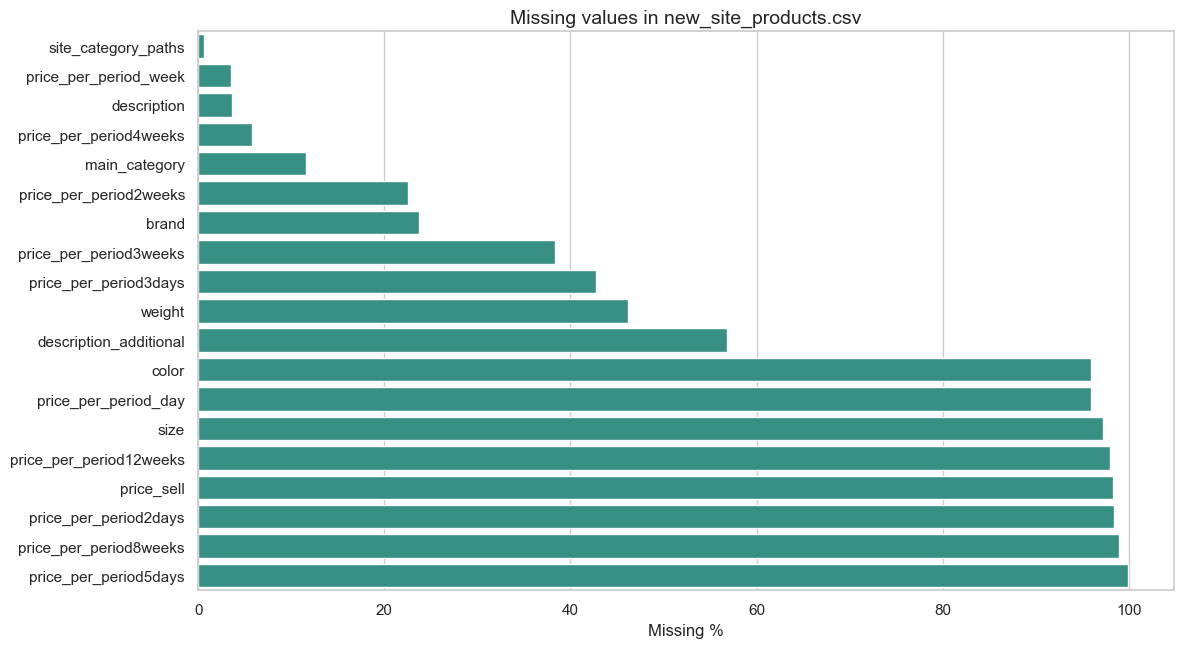

In [12]:
new_products = pd.read_csv(ROOT / 'new_site_products.csv')
show_basic_profile(new_products, 'new_site_products.csv')

print('Rows:', len(new_products))
print('Unique products:', new_products['id'].nunique())
print('Unique brands:', new_products['brand'].nunique(dropna=True))
print('Unique main categories:', new_products['main_category'].nunique(dropna=True))
print('Unique slugs:', new_products['slug'].nunique(dropna=True))

product_profile = profile_dataframe(new_products)
plot_missing(product_profile, 'Missing values in new_site_products.csv')

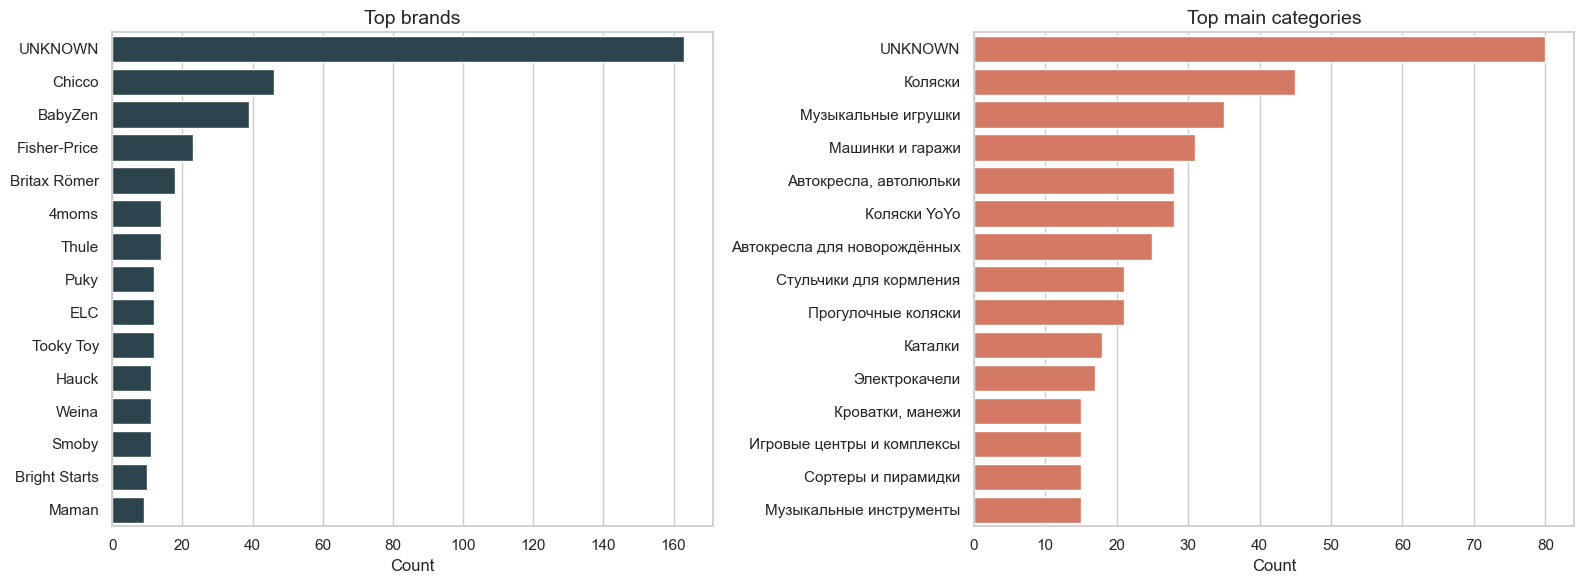

,count,mean,std,min,25%,50%,75%,max
price_per_period_day,28.0,1335.714286,1326.988874,500.0,600.0,850.0,1800.0,7500.0
price_per_period2days,11.0,1090.909091,258.667916,800.0,800.0,1100.0,1350.0,1400.0
price_per_period3days,394.0,1706.218274,1655.238631,300.0,900.0,1100.0,2100.0,17700.0
price_per_period5days,1.0,12100.000000,NaN,12100.0,12100.0,12100.0,12100.0,12100.0
price_per_period_week,664.0,2101.807229,1740.788223,300.0,1100.0,1500.0,2525.0,16400.0
price_per_period2weeks,533.0,2759.943715,2123.862941,300.0,1400.0,2000.0,3400.0,14300.0
price_per_period3weeks,424.0,2992.334906,2157.603844,700.0,1500.0,2100.0,3500.0,10100.0
price_per_period4weeks,648.0,3225.540123,2538.271148,500.0,1500.0,2400.0,3800.0,14700.0
price_per_period8weeks,7.0,4871.428571,3533.513023,2000.0,2200.0,3300.0,6500.0,11400.0
price_per_period12weeks,14.0,10750.000000,9089.279399,2100.0,3125.0,7000.0,17800.0,25900.0


In [13]:
top_brands = new_products['brand'].fillna('UNKNOWN').value_counts().head(15)
top_categories = new_products['main_category'].fillna('UNKNOWN').value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x=top_brands.values, y=top_brands.index, ax=axes[0], color='#264653')
axes[0].set_title('Top brands')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('')

sns.barplot(x=top_categories.values, y=top_categories.index, ax=axes[1], color='#e76f51')
axes[1].set_title('Top main categories')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

price_cols = [c for c in new_products.columns if c.startswith('price_per_period') or c == 'price_sell']
display(new_products[price_cols].describe(include='all').T)

## 4. EDA bảng sản phẩm cũ và mapping giữa hai site

Phần này giúp hiểu dữ liệu lịch sử, mức độ tương thích giữa hai hệ thống, và khả năng tận dụng dữ liệu cũ để tăng độ phủ cho item space.

=== old_site_products.csv ===


,id,name,brand,main_category,categories,price_per_period3days,price_per_period_week,price_per_period_month,partner_id,description,weight,size,slug,age_zero_six_month,age_six_twelve_month,age_one_two_years,age_two_three_years,age_three_four_years,age_four_five_years,age_six_plus_years,param_child_weight,param_group,param_material,param_safety_standards,param_mount_type,param_seat_type,param_installation,param_child_fixation,param_additional_functions,param_configuration,param_features,param_speed_count,param_max_load,param_operating_principle,param_rocking_modes,param_seat_belts,param_max_child_weight,param_backrest_sleeping_positions,param_stroller_type,param_accessories,param_price_range,param_wheel_type,param_wheel_count,param_type,param_foreign_languages,param_melodies_and_sounds,param_volume_levels,param_elements_count,param_toy_type,param_functions,param_arc_count,param_child_unit_power,param_child_unit_functions,param_parent_unit_functions,param_roleplay_toy_type,param_discreteness,param_shape,param_param_weight,param_bike_seat_mount,param_kind,param_mount,param_melodies,param_melody_count,param_hanging_toy_count,param_chair_type,param_child_positions,param_carrying_method,param_table_type,param_mobility,param_adjustment,param_water_tank_volume,param_other,param_screen_diagonal,param_parent_unit_power
0,3259,Автокресло Baby Care BSO Sport Isofix,Baby Care,Автокресла,"[""Автокресла"",""Прогулки и путешествия""]",NaN,NaN,NaN,NaN,"<p><span style=""font-size: 14px;"">Baby Care BSO Sport Isofix &ndash; удобное детское автокресло, установленное в лит...","7,3 кг",48х68х61 см,avtokreslo-baby-care-bso-sport-isofix,False,False,False,False,False,False,False,"[""9-18""]","[""Группа 1 (9-18 кг)""]","[""пластик"",""полиэстер""]","[""Стандарт ECE R44/04""]","[""isofix""]","[""автокресло""]","[""по направлению движения""]","[""пятиточечные ремни""]",[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]
1,3261,Автокресло Chicco Key1 X-Plus ISOFIX,Chicсo,Автокресла,"[""Автокресла"",""Прогулки и путешествия""]",1100.0,1800.0,2700.0,1.0,"<p><span style=""font-size: 14px;""><span style=""font-family: Tahoma;"">Детское автомобильное кресло Chicco Key1 X-Plus...","12,9 кг",50x43x66 см,avtokreslo-chicco-key1-x-plus-isofix,False,False,False,False,False,False,False,"[""9-18""]","[""Группа 1 (9-18 кг)""]","[""пластик"",""полиэстер""]","[""Стандарт ECE R44/04""]","[""isofix""]","[""автокресло""]","[""по направлению движения""]","[""пятиточечные ремни""]",[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]
2,3262,Автокресло Chicco Synthesis XT-Plus,Chicсo,Автокресла,"[""Автокресла"",""Прогулки и путешествия""]",600.0,1000.0,1800.0,1.0,"<ul>\n <li style=""text-align: justify;""><span style=""font-size: 14px;"">Комфортное и безопасное автокресло-люлька ...",3.3 кг,56х67х45 см,avtokreslo-chicco-synthesis-xt-plus,False,False,False,False,False,False,False,[],"[""Группа 0 (0-13 кг)""]","[""пластик"",""полиэстер""]","[""Стандарт ECE R44/04""]","[""штатный ремень безопасности""]",[],"[""против направления движения""]","[""трёхточечные ремни""]",[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]
3,3265,Дом-палатка с туннелем «Океан»,Ching-Ching,Домики и палатки,"[""Домики и палатки"",""Тренажеры и игровые комплексы""]",500.0,700.0,1000.0,1.0,"<p><span style=""font-size: 14px;"">Игровой домик-палатка с туннелем нравится всем малышам! Тут можно прятаться, полза...",NaN,NaN,dom-palatka-s-tunnelem-okean,False,False,False,False,False,False,False,[],[],[],[],[],[],[],[],"[""Шарики""]","[""Туннель""]",[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]
4,3267,Барабан для малышей,Imaginarium,NaN,[],NaN,NaN,NaN,NaN,"<p><span style=""fo

,column,dtype,missing,missing_pct,n_unique,sample_values
0,id,int64,0,0.000000,761,"3259, 3261, 3262"
1,name,str,0,0.000000,760,"Автокресло Baby Care BSO Sport Isofix, Автокресло Chicco Key1 X-Plus ISOFIX, Автокресло Chicco Synthesis XT-Plus"
2,brand,str,23,3.022339,125,"Baby Care, Chicсo, Chicсo"
3,main_category,str,104,13.666229,48,"Автокресла, Автокресла, Автокресла"
4,categories,str,0,0.000000,108,"[""Автокресла"",""Прогулки и путешествия""], [""Автокресла"",""Прогулки и путешествия""], [""Автокресла"",""Прогулки и путешест..."
...,...,...,...,...,...,...
69,param_adjustment,str,0,0.000000,6,"[], [], []"
70,param_water_tank_volume,str,0,0.000000,3,"[], [], []"
71,param_other,str,0,0.000000,4,"[], [], []"
72,param_screen_diagonal,str,0,0.000000,3,"[], [], []"


=== old_site_new_site_products.csv ===


,old_site_id,new_site_id
0,3601,463480211
1,3282,463480213
2,3314,463480214
3,3384,463480224
4,3383,463480225


,column,dtype,missing,missing_pct,n_unique,sample_values
0,old_site_id,int64,0,0.0,420,"3601, 3282, 3314"
1,new_site_id,int64,0,0.0,464,"463480211, 463480213, 463480214"


Old products: 761
New products: 668
Mapped old products: 420
Mapped new products: 464


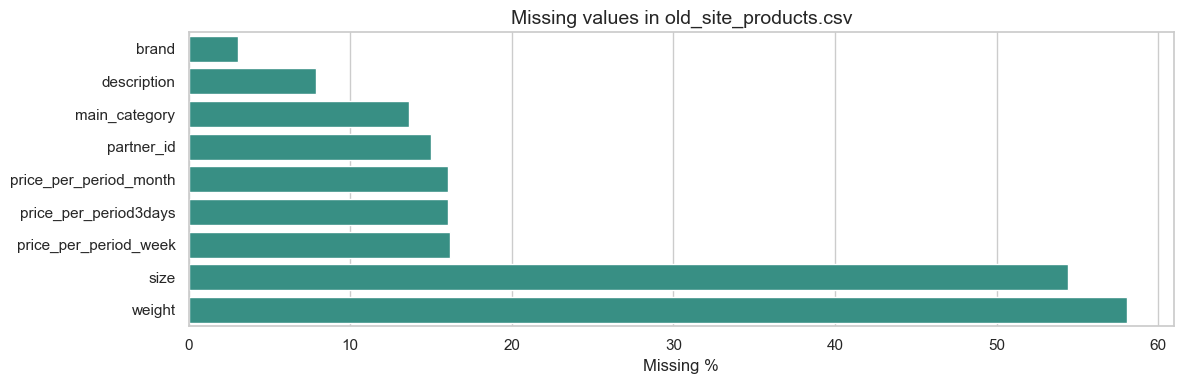

In [14]:
old_products = pd.read_csv(ROOT / 'old_site_products.csv')
mapping = pd.read_csv(ROOT / 'old_site_new_site_products.csv')

show_basic_profile(old_products, 'old_site_products.csv')
show_basic_profile(mapping, 'old_site_new_site_products.csv')

print('Old products:', old_products['id'].nunique())
print('New products:', new_products['id'].nunique())
print('Mapped old products:', mapping['old_site_id'].nunique())
print('Mapped new products:', mapping['new_site_id'].nunique())

plot_missing(profile_dataframe(old_products), 'Missing values in old_site_products.csv')

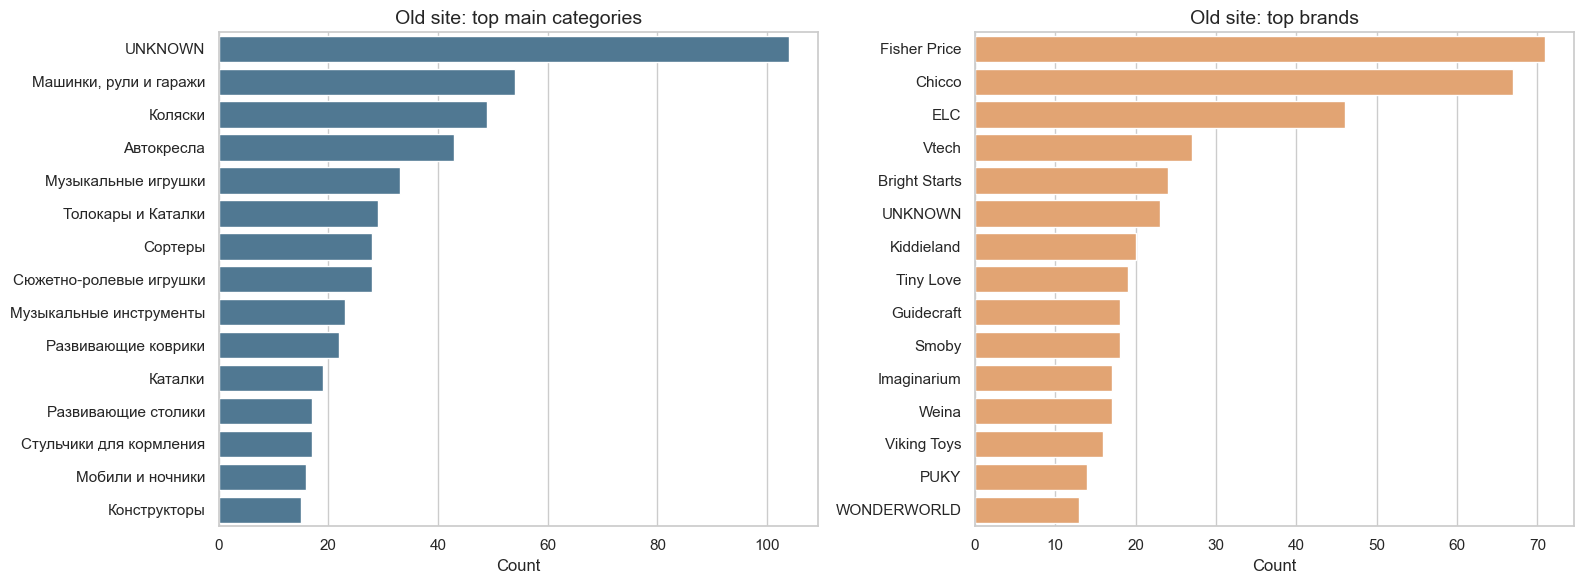

In [15]:
old_cat = old_products['main_category'].fillna('UNKNOWN').value_counts().head(15)
old_brand = old_products['brand'].fillna('UNKNOWN').value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x=old_cat.values, y=old_cat.index, ax=axes[0], color='#457b9d')
axes[0].set_title('Old site: top main categories')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('')

sns.barplot(x=old_brand.values, y=old_brand.index, ax=axes[1], color='#f4a261')
axes[1].set_title('Old site: top brands')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

## 5. EDA các bảng đơn hàng và giỏ hàng

Hai bảng này phản ánh hành vi gần với mục tiêu gợi ý: tần suất thuê, giá trị đơn hàng, trạng thái, hình thức nhận hàng, và sản phẩm được chọn.

In [16]:
new_orders = pd.read_csv(ROOT / 'new_site_orders.csv')
old_orders = pd.read_csv(ROOT / 'old_site_orders.csv')
old_carts = pd.read_csv(ROOT / 'old_site_carts.csv')

show_basic_profile(new_orders, 'new_site_orders.csv')
show_basic_profile(old_orders, 'old_site_orders.csv')
show_basic_profile(old_carts, 'old_site_carts.csv')

for df, name, date_cols in [
    (new_orders, 'new_site_orders', ['create_date', 'start_date', 'end_date', 'modified_on']),
    (old_orders, 'old_site_orders', ['create_date', 'start_date', 'end_date', 'modified_on']),
    (old_carts, 'old_site_carts', ['delivery_date', 'modified_on'])
]:
    converted = add_datetime_columns(df, date_cols)
    print(f'\n{name}:')
    for col in date_cols:
        if col in converted.columns:
            print(col, 'range =', converted[col].min(), '->', converted[col].max())

display(profile_dataframe(new_orders))
display(profile_dataframe(old_orders))
display(profile_dataframe(old_carts))

=== new_site_orders.csv ===


,id,number,user_id,create_date,start_date,end_date,rental_days,status_code,total_amount,rental_amount,promo_discount_percent,discount_amount,shipping_type,shipping_amount,return_amount,source_type,product_id,product_price,product_discount_amount,color,modified_on
0,24690,1004,23244,2025-03-14T17:01,2025-03-15,2025-03-22,7,ERROR,2650.0,2200.0,NaN,0.0,DELIVERY,450.0,0.0,SITE,463480227,2200.0,0.0,NaN,2025-03-18T14:17:16
1,24691,1005,23245,2025-03-16T15:19,2025-03-16,2025-03-23,7,ERROR,1850.0,1400.0,NaN,0.0,DELIVERY,450.0,0.0,SITE,463480213,1400.0,0.0,NaN,2025-03-18T14:17:16
2,24692,1006,23246,2025-03-17T13:28,2025-03-17,2025-03-22,7,CANCEL,2590.0,1790.0,NaN,0.0,DELIVERY,800.0,0.0,SITE,463480571,1790.0,0.0,NaN,2025-03-18T14:23:54
3,24693,24693C,23247,2025-03-17T16:11,2025-03-19,2025-03-26,7,ORDERFINISH,3950.0,3500.0,NaN,0.0,DELIVERY,450.0,0.0,OTHER,463480487,2200.0,0.0,NaN,2025-04-02T12:55:04
4,24693,24693C,23247,2025-03-17T16:11,2025-03-19,2025-03-26,7,ORDERFINISH,3950.0,3500.0,NaN,0.0,DELIVERY,450.0,0.0,OTHER,463480382,1300.0,0.0,NaN,2025-04-02T12:55:04


,column,dtype,missing,missing_pct,n_unique,sample_values
0,id,int64,0,0.000000,2259,"24690, 24691, 24692"
1,number,str,0,0.000000,2259,"1004, 1005, 1006"
2,user_id,int64,0,0.000000,2109,"23244, 23245, 23246"
3,create_date,str,0,0.000000,2239,"2025-03-14T17:01, 2025-03-16T15:19, 2025-03-17T13:28"
4,start_date,str,0,0.000000,217,"2025-03-15, 2025-03-16, 2025-03-17"
5,end_date,str,137,4.795240,244,"2025-03-22, 2025-03-23, 2025-03-22"
6,rental_days,int64,0,0.000000,9,"7, 7, 7"
7,status_code,str,0,0.000000,5,"ERROR, ERROR, CANCEL"
8,total_amount,float64,0,0.000000,588,"2650.0, 1850.0, 2590.0"
9,rental_amount,float64,0,0.000000,466,"2200.0, 1400.0, 1790.0"


=== old_site_orders.csv ===


,id,user_id,create_date,start_date,end_date,rental_days,status_code,rental_amount,promo_discount_percent,shipping_type,shipping_amount,return_amount,source_type,product_id,modified_on
0,43934,11591.0,2021-11-25,2021-11-25,2021-11-26,NaN,ORDERFINISH,4200.0,NaN,DELIVERY,0.0,0.0,NaN,3867,2021-11-25T11:29:38
1,43934,11591.0,2021-11-25,2021-11-25,2021-11-26,NaN,ORDERFINISH,4200.0,NaN,DELIVERY,0.0,0.0,NaN,3793,2021-11-25T11:29:38
2,43934,11591.0,2021-11-25,2021-11-25,2021-11-26,NaN,ORDERFINISH,4200.0,NaN,DELIVERY,0.0,0.0,NaN,3564,2021-11-25T11:29:38
3,43934,11591.0,2021-11-25,2021-11-25,2021-11-26,NaN,ORDERFINISH,4200.0,NaN,DELIVERY,0.0,0.0,NaN,3512,2021-11-25T11:29:38
4,43934,11591.0,2021-11-25,2021-11-25,2021-11-26,NaN,ORDERFINISH,4200.0,NaN,DELIVERY,0.0,0.0,NaN,3530,2021-11-25T11:29:38


...

,column,dtype,missing,missing_pct,n_unique,sample_values
0,id,int64,0,0.000000,12762,"6, 7, 8"
1,user_id,float64,11628,55.799223,3768,"2.0, 2.0, 2.0"
2,order_id,float64,13034,62.546187,4365,"43459.0, 43461.0, 43465.0"
3,rental_days,float64,11,0.052786,3,"7.0, 30.0, 7.0"
4,promo_discount_percent,float64,20034,96.137051,5,"20.0, 20.0, 20.0"
5,delivery_date,str,15,0.071980,12353,"2021-10-22T13:10:37, 2021-10-22T13:11:49, 2021-10-22T16:59:30"
6,modified_on,str,9239,44.335141,7272,"2021-10-21T16:10:49, 2021-10-21T16:13:23, 2021-10-21T20:37:10"
7,cart_item_id,int64,0,0.000000,20839,"22958, 22959, 22960"
8,cart_item_deleted,bool,0,0.000000,1,"False, False, False"
9,product_id,int64,0,0.000000,629,"3447, 3460, 3259"



new_site_orders:
create_date range = 2025-03-14 17:01:00 -> 2025-11-05 10:37:00
start_date range = 1970-01-01 00:00:00 -> 2026-08-25 00:00:00
end_date range = 2025-03-22 00:00:00 -> 2026-09-08 00:00:00
modified_on range = 2025-03-18 14:17:16 -> 2025-11-05 15:30:36

old_site_orders:
create_date range = 2021-11-24 00:00:00 -> 2025-07-31 00:00:00
start_date range = 2021-02-01 00:00:00 -> 2025-11-26 00:00:00
end_date range = 2021-02-07 00:00:00 -> 2025-11-28 00:00:00
modified_on range = 2021-11-25 11:29:38 -> 2025-07-31 16:32:43

old_site_carts:
delivery_date range = 2021-10-22 13:10:37 -> 2025-06-12 16:17:21
modified_on range = 2021-10-21 16:10:49 -> 2024-02-01 23:22:26


,column,dtype,missing,missing_pct,n_unique,sample_values
0,id,int64,0,0.000000,2259,"24690, 24691, 24692"
1,number,str,0,0.000000,2259,"1004, 1005, 1006"
2,user_id,int64,0,0.000000,2109,"23244, 23245, 23246"
3,create_date,str,0,0.000000,2239,"2025-03-14T17:01, 2025-03-16T15:19, 2025-03-17T13:28"
4,start_date,str,0,0.000000,217,"2025-03-15, 2025-03-16, 2025-03-17"
5,end_date,str,137,4.795240,244,"2025-03-22, 2025-03-23, 2025-03-22"
6,rental_days,int64,0,0.000000,9,"7, 7, 7"
7,status_code,str,0,0.000000,5,"ERROR, ERROR, CANCEL"
8,total_amount,float64,0,0.000000,588,"2650.0, 1850.0, 2590.0"
9,rental_amount,float64,0,0.000000,466,"2200.0, 1400.0, 1790.0"


,column,dtype,missing,missing_pct,n_unique,sample_values
0,id,int64,0,0.000000,12376,"43934, 43934, 43934"
1,user_id,float64,8,0.044680,7005,"11591.0, 11591.0, 11591.0"
2,create_date,str,0,0.000000,1317,"2021-11-25, 2021-11-25, 2021-11-25"
3,start_date,str,2,0.011170,1321,"2021-11-25, 2021-11-25, 2021-11-25"
4,end_date,str,19,0.106116,1342,"2021-11-26, 2021-11-26, 2021-11-26"
5,rental_days,float64,11673,65.194080,3,"7.0, 7.0, 3.0"
6,status_code,str,0,0.000000,7,"ORDERFINISH, ORDERFINISH, ORDERFINISH"
7,rental_amount,float64,0,0.000000,355,"4200.0, 4200.0, 4200.0"
8,promo_discount_percent,float64,17380,97.067858,6,"20.0, 40.0, 40.0"
9,shipping_type,str,2577,14.392628,2,"DELIVERY, DELIVERY, DELIVERY"


,column,dtype,missing,missing_pct,n_unique,sample_values
0,id,int64,0,0.000000,12762,"6, 7, 8"
1,user_id,float64,11628,55.799223,3768,"2.0, 2.0, 2.0"
2,order_id,float64,13034,62.546187,4365,"43459.0, 43461.0, 43465.0"
3,rental_days,float64,11,0.052786,3,"7.0, 30.0, 7.0"
4,promo_discount_percent,float64,20034,96.137051,5,"20.0, 20.0, 20.0"
5,delivery_date,str,15,0.071980,12353,"2021-10-22T13:10:37, 2021-10-22T13:11:49, 2021-10-22T16:59:30"
6,modified_on,str,9239,44.335141,7272,"2021-10-21T16:10:49, 2021-10-21T16:13:23, 2021-10-21T20:37:10"
7,cart_item_id,int64,0,0.000000,20839,"22958, 22959, 22960"
8,cart_item_deleted,bool,0,0.000000,1,"False, False, False"
9,product_id,int64,0,0.000000,629,"3447, 3460, 3259"


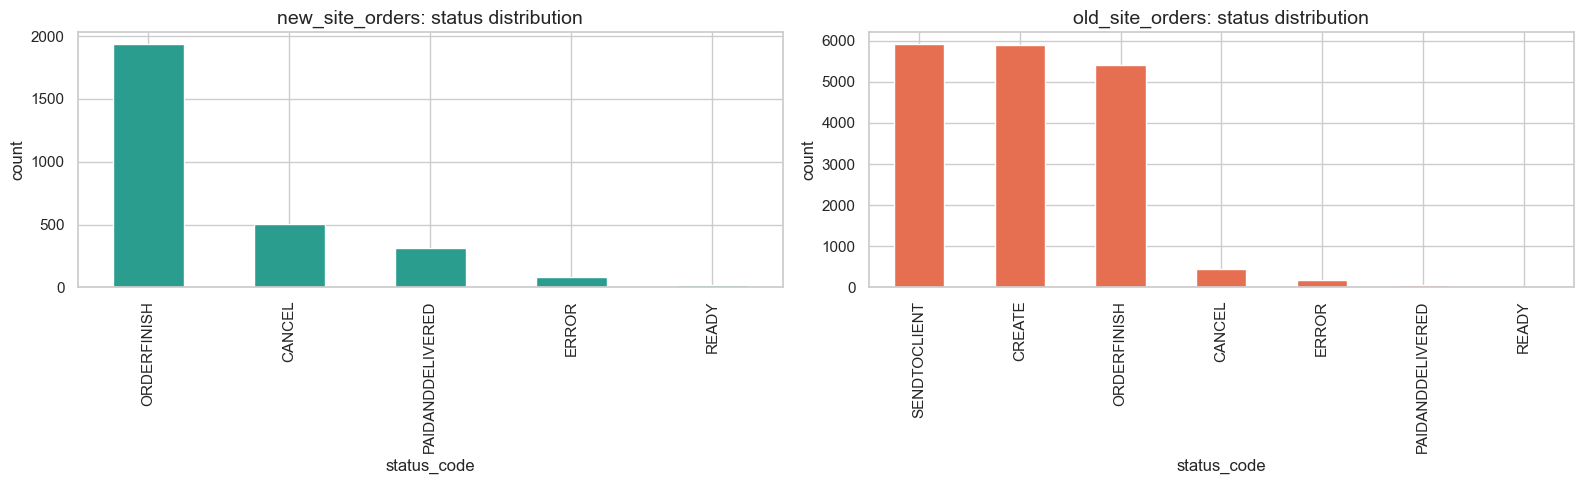

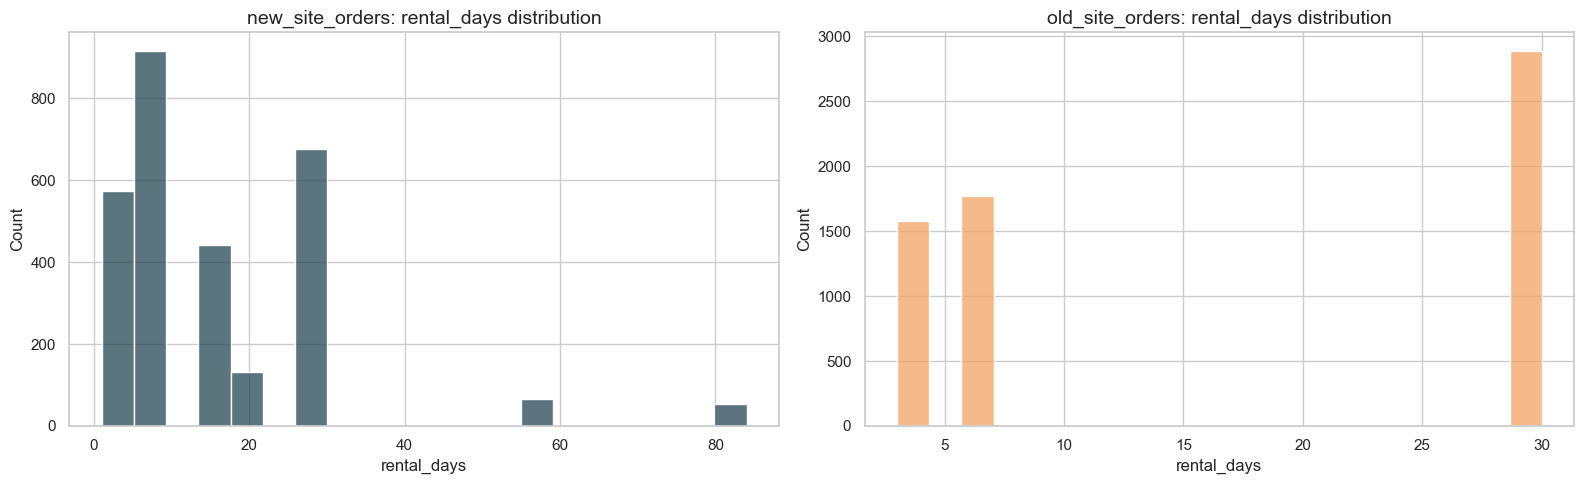

,count,mean,std,min,25%,50%,75%,max
total_amount,2857.0,3693.786139,3033.988910,0.0,1850.0,2800.0,4650.0,27450.0
rental_amount,2857.0,3369.946447,3013.386054,0.0,1500.0,2470.0,4310.0,27000.0
shipping_amount,2857.0,323.839692,332.985276,0.0,0.0,450.0,500.0,3000.0
discount_amount,2857.0,76.180959,289.709622,0.0,0.0,0.0,0.0,3900.0
return_amount,2857.0,85.505775,189.847623,0.0,0.0,0.0,0.0,960.0


In [17]:
new_orders_dt = add_datetime_columns(new_orders, ['create_date', 'start_date', 'end_date', 'modified_on'])
old_orders_dt = add_datetime_columns(old_orders, ['create_date', 'start_date', 'end_date', 'modified_on'])
old_carts_dt = add_datetime_columns(old_carts, ['delivery_date', 'modified_on'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
new_orders_dt['status_code'].fillna('UNKNOWN').value_counts().plot(kind='bar', ax=axes[0], color='#2a9d8f')
axes[0].set_title('new_site_orders: status distribution')
axes[0].set_xlabel('status_code')
axes[0].set_ylabel('count')

old_orders_dt['status_code'].fillna('UNKNOWN').value_counts().plot(kind='bar', ax=axes[1], color='#e76f51')
axes[1].set_title('old_site_orders: status distribution')
axes[1].set_xlabel('status_code')
axes[1].set_ylabel('count')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(new_orders_dt['rental_days'].dropna(), bins=20, ax=axes[0], color='#264653')
axes[0].set_title('new_site_orders: rental_days distribution')
sns.histplot(old_orders_dt['rental_days'].dropna(), bins=20, ax=axes[1], color='#f4a261')
axes[1].set_title('old_site_orders: rental_days distribution')
plt.tight_layout()
plt.show()

display(new_orders_dt[['total_amount', 'rental_amount', 'shipping_amount', 'discount_amount', 'return_amount']].describe().T)

## 6. Profiling toàn bộ log hành vi lớn bằng chunk

Đây là phần nặng nhất của EDA. Thay vì load toàn bộ vào RAM, notebook đọc từng phần để đếm số dòng, giá trị thiếu, giá trị phổ biến và thống kê cột quan trọng.

In [18]:
hits_main = ROOT / 'metrika_hits.csv'
hits_test = ROOT / 'metrika_hits_test.csv'
visits_main = ROOT / 'metrika_visits.csv'
visits_test = ROOT / 'metrika_visits_test.csv'

hits_profile = chunk_profile(hits_main)
hits_test_profile = chunk_profile(hits_test)
visits_profile = chunk_profile(visits_main)
visits_test_profile = chunk_profile(visits_test)

print('metrika_hits.csv rows:', hits_profile['rows'])
display(hits_profile['summary'])
print('metrika_hits_test.csv rows:', hits_test_profile['rows'])
display(hits_test_profile['summary'])
print('metrika_visits.csv rows:', visits_profile['rows'])
display(visits_profile['summary'])
print('metrika_visits_test.csv rows:', visits_test_profile['rows'])
display(visits_test_profile['summary'])

metrika_hits.csv rows: 1757619


,column,dtype,missing,missing_pct,approx_unique
19,last_social_network_profile,str,1757589,100.00,28
21,messenger,str,1755119,99.86,1
20,recommendation_system,str,1738574,98.92,4
18,last_social_network,str,1736733,98.81,12
15,last_search_engine_root,str,1599228,90.99,9
16,last_search_engine,str,1599228,90.99,18
17,last_adv_engine,str,1558205,88.65,6
23,mobile_phone,str,395858,22.52,40
24,mobile_phone_model,str,389016,22.13,1020
5,region_city,str,320244,18.22,350


metrika_hits_test.csv rows: 6880


,column,dtype,missing,missing_pct,approx_unique
21,messenger,float64,6880,100.00,0
19,last_social_network_profile,float64,6880,100.00,0
18,last_social_network,str,6872,99.88,2
20,recommendation_system,str,6856,99.65,1
17,last_adv_engine,str,6233,90.60,1
16,last_search_engine,str,5888,85.58,6
15,last_search_engine_root,str,5888,85.58,2
23,mobile_phone,str,1226,17.82,19
24,mobile_phone_model,str,1217,17.69,168
8,slug,str,1134,16.48,353


metrika_visits.csv rows: 345214


,column,dtype,missing,missing_pct,approx_unique
14,messenger,str,344001,99.65,1
13,recommendation_system,str,339157,98.25,6
12,social_network,str,334040,96.76,11
11,search_engine,str,234003,67.78,14
10,search_engine_root,str,234003,67.78,9
16,mobile_phone,str,74743,21.65,41
17,mobile_phone_model,str,73185,21.20,1005
6,region_city,str,60367,17.49,378
5,region_country,str,1757,0.51,52
18,operating_system_root,str,1272,0.37,6


metrika_visits_test.csv rows: 1363


,column,dtype,missing,missing_pct,approx_unique
14,messenger,float64,1363,100.00,0
12,social_network,str,1357,99.56,2
13,recommendation_system,str,1352,99.19,1
11,search_engine,str,776,56.93,5
10,search_engine_root,str,776,56.93,2
6,region_city,str,201,14.75,154
16,mobile_phone,str,194,14.23,19
17,mobile_phone_model,str,192,14.09,186
5,region_country,str,11,0.81,44
4,client_id,uint64,0,0.00,1363


,project_id,watch_id,date_time,page_type,slug,is_page_view
0,1,8194662451870622352,2021-11-24 00:06:51,PRODUCT,igrovoy-derevyannyy-stolik-elc-bolshoy,1
1,1,7945031156395861140,2021-11-24 00:09:06,MAIN,NaN,1
2,1,6365098314568244974,2021-11-24 00:09:07,MAIN,NaN,1
3,1,5280229437160873424,2021-11-24 00:09:21,MAIN,NaN,0
4,1,133574988465249163,2021-11-24 00:09:52,MAIN,NaN,1


Page types: {'CATEGORY': 262765, 'PRODUCT': 109013, 'MAIN': 91620, 'INFO': 19634, 'CART': 8309, 'INVALID_PATH': 2784, 'CHECKOUT': 2252, 'PROFILE': 1913, 'ORDER': 1460, 'WISHLIST': 250}
Project IDs: {1: 500000}


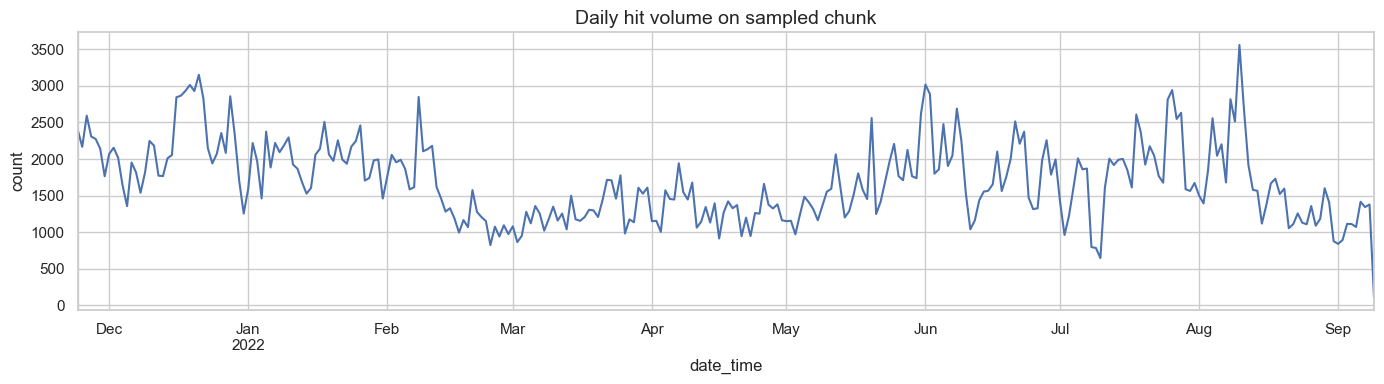

In [19]:
# Read only the useful columns from hits for temporal and behavioral analysis
hits_cols = ['date_time', 'slug', 'page_type', 'project_id', 'is_page_view', 'watch_id']
hits_sample = pd.read_csv(hits_main, usecols=hits_cols, nrows=500000, low_memory=False)
hits_sample['date_time'] = pd.to_datetime(hits_sample['date_time'], errors='coerce')
hits_sample['page_type'] = hits_sample['page_type'].fillna('UNKNOWN')
hits_sample['is_page_view'] = hits_sample['is_page_view'].fillna('0')

display(hits_sample.head())
print('Page types:', hits_sample['page_type'].value_counts().head(20).to_dict())
print('Project IDs:', hits_sample['project_id'].fillna('UNKNOWN').value_counts().head(20).to_dict())

daily_hits = hits_sample.dropna(subset=['date_time']).set_index('date_time').resample('D').size()
daily_hits.plot(figsize=(14, 4), title='Daily hit volume on sampled chunk')
plt.ylabel('count')
plt.tight_layout()
plt.show()

,visit_id,client_id,watch_ids,watch_count
0,8194662451870622352,203466395347938108,[8194662451870622352],1
1,7945031156395861140,98977237931745921755,"[7945031156395861140, 6365098314568244974, 4360519987250864829, 8839619398535951284, 5280229437160873424]",5
2,5420922249421956816,1507358969798591332,"[5420922249421956816, 0133574988465249163, 4637999082422526606, 9770649425757685972, 3903280002174288649, 3211397459...",10
3,489921271575084095,8074332370446781156,"[0489921271575084095, 1468482791524947292, 5014801916752504268, 5354853449359706279, 2343813338249178418, 5709984559...",7
4,9711995390232124595,3390781681265368021,"[9711995390232124595, 7105505645939557161, 1013330949570254802, 0156513630068488961]",4


count    200000.000000
mean          8.459080
std          15.728296
min           1.000000
25%           2.000000
50%           4.000000
75%           8.000000
max         500.000000
Name: watch_count, dtype: float64

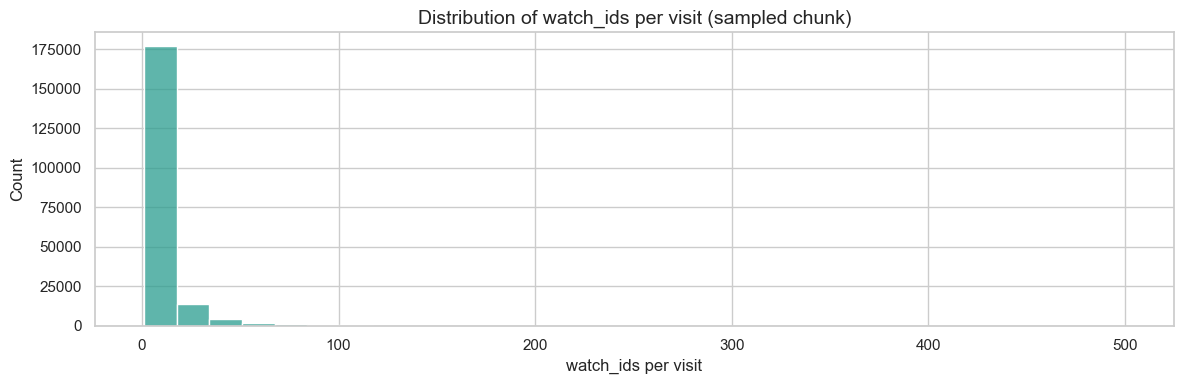

In [20]:
visits_cols = ['client_id', 'visit_id', 'watch_ids']
visits_sample = pd.read_csv(visits_main, usecols=visits_cols, nrows=200000, low_memory=False)
visits_sample['watch_ids'] = visits_sample['watch_ids'].apply(ast.literal_eval)
visits_sample['watch_count'] = visits_sample['watch_ids'].apply(len)

display(visits_sample.head())
display(visits_sample['watch_count'].describe())

fig, ax = plt.subplots(figsize=(12, 4))
sns.histplot(visits_sample['watch_count'], bins=30, ax=ax, color='#2a9d8f')
ax.set_title('Distribution of watch_ids per visit (sampled chunk)')
ax.set_xlabel('watch_ids per visit')
plt.tight_layout()
plt.show()

## 7. Liên kết giữa hits và visits

Mối nối quan trọng nhất của log là `watch_id`. Notebook kiểm tra độ khớp giữa hai bảng để biết liệu có thể dựng session-level behavior chính xác hay không.

In [21]:
hits_watch = pd.read_csv(hits_main, usecols=['watch_id'], low_memory=False)
visits_watch = pd.read_csv(visits_main, usecols=['watch_ids'], low_memory=False)
visits_watch['watch_ids'] = visits_watch['watch_ids'].apply(ast.literal_eval)

hits_unique = set(hits_watch['watch_id'].dropna().astype(str).head(500000))
visits_flat = visits_watch['watch_ids'].explode().dropna().astype(str)
visits_unique = set(visits_flat.head(500000))

intersection = len(hits_unique & visits_unique)
union = len(hits_unique | visits_unique)
print('Approx unique watch_id in sampled hits:', len(hits_unique))
print('Approx unique watch_id in sampled visits:', len(visits_unique))
print('Approx overlap:', intersection)
print('Approx Jaccard:', round(intersection / union if union else 0, 4))

Approx unique watch_id in sampled hits: 500000
Approx unique watch_id in sampled visits: 500000
Approx overlap: 276203
Approx Jaccard: 0.3816


## 8. Phân tích hành vi theo page type và funnel

Ở đây ta xem các loại hành vi nào xuất hiện nhiều nhất, và thứ tự page type phổ biến trong cùng một visit. Điều này giúp hiểu ý định người dùng trước khi tạo mô hình sequence.

,count
page_type,
CATEGORY,512428
PRODUCT,256580
MAIN,151941
INFO,43701
CART,19567
CHECKOUT,4920
PROFILE,3669
ORDER,3496
INVALID_PATH,3178


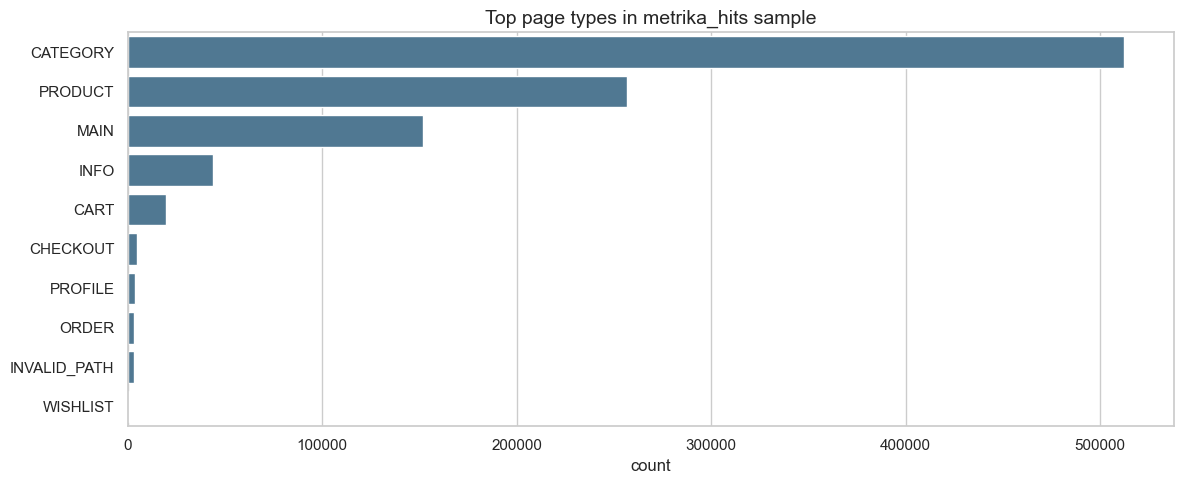

,count
page_type,
"(CATEGORY,)",512428
"(PRODUCT,)",256580
"(MAIN,)",151941
"(INFO,)",43701
"(CART,)",19567
"(CHECKOUT,)",4920
"(PROFILE,)",3669
"(ORDER,)",3496
"(INVALID_PATH,)",3178


In [22]:
hits_small = pd.read_csv(hits_main, usecols=hits_cols, nrows=1000000, low_memory=False)
hits_small['date_time'] = pd.to_datetime(hits_small['date_time'], errors='coerce')
hits_small['page_type'] = hits_small['page_type'].fillna('UNKNOWN')
hits_small['project_id'] = hits_small['project_id'].fillna('UNKNOWN')

page_counts = hits_small['page_type'].value_counts().head(20)
display(page_counts.to_frame('count'))

plt.figure(figsize=(12, 5))
sns.barplot(x=page_counts.values, y=page_counts.index, color='#457b9d')
plt.title('Top page types in metrika_hits sample')
plt.xlabel('count')
plt.ylabel('')
plt.tight_layout()
plt.show()

visit_seq = hits_small.sort_values('date_time').groupby('watch_id')['page_type'].apply(lambda x: tuple(x.head(8))).value_counts().head(15)
display(visit_seq.to_frame('count'))

## 9. Phân tích temporal dynamics

Bài toán thuê thường có tính mùa vụ và nhịp lặp. Phần này xem phân bố theo ngày/giờ để nhận diện pattern thời gian.

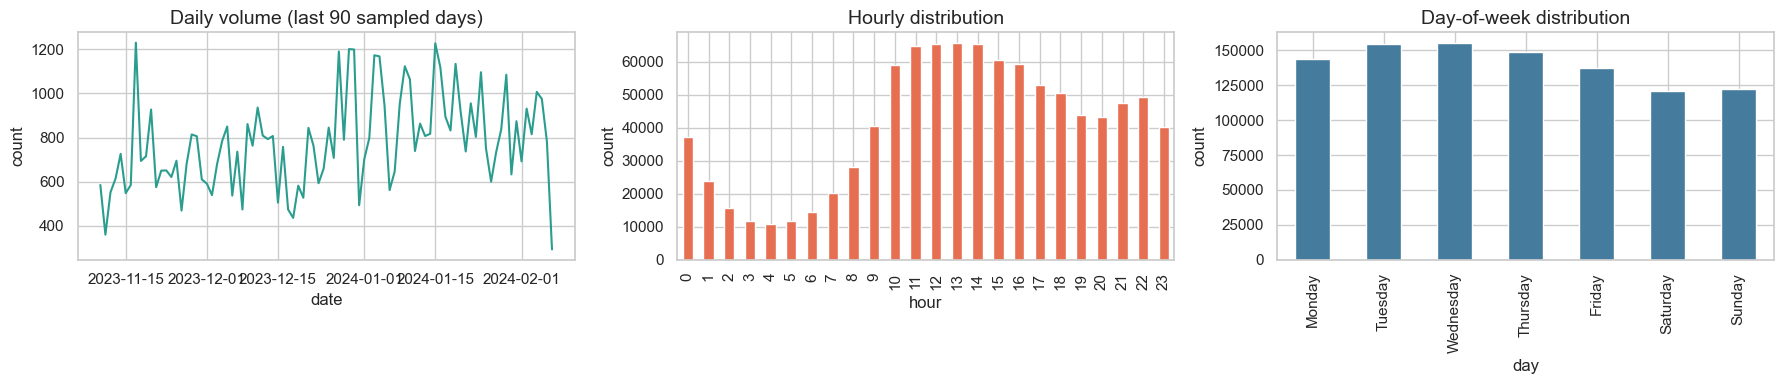

In [23]:
hits_time = hits_small.dropna(subset=['date_time']).copy()
hits_time['date'] = hits_time['date_time'].dt.date
hits_time['hour'] = hits_time['date_time'].dt.hour
hits_time['dow'] = hits_time['date_time'].dt.day_name()

daily = hits_time.groupby('date').size()
hourly = hits_time.groupby('hour').size()
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow = hits_time.groupby('dow').size().reindex(dow_order)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
daily.tail(90).plot(ax=axes[0], color='#2a9d8f')
axes[0].set_title('Daily volume (last 90 sampled days)')
axes[0].set_ylabel('count')

hourly.plot(kind='bar', ax=axes[1], color='#e76f51')
axes[1].set_title('Hourly distribution')
axes[1].set_xlabel('hour')
axes[1].set_ylabel('count')

dow.plot(kind='bar', ax=axes[2], color='#457b9d')
axes[2].set_title('Day-of-week distribution')
axes[2].set_xlabel('day')
axes[2].set_ylabel('count')
plt.tight_layout()
plt.show()

## 10. Phân tích các thuộc tính quan trọng trong sản phẩm

Ta kiểm tra giá, kích thước, category path, age flags và mức độ đầy đủ của metadata. Đây là cơ sở để quyết định có nên dùng content-based feature hay chỉ dùng ID.


=== main_category ===
main_category
UNKNOWN                         80
Коляски                         45
Музыкальные игрушки             35
Машинки и гаражи                31
Автокресла, автолюльки          28
Коляски YoYo                    28
Автокресла для новорождённых    25
Стульчики для кормления         21
Прогулочные коляски             21
Каталки                         18
Name: count, dtype: int64

=== brand ===
brand
UNKNOWN         163
Chicco           46
BabyZen          39
Fisher-Price     23
Britax Römer     18
4moms            14
Thule            14
Puky             12
ELC              12
Tooky Toy        12
Name: count, dtype: int64

=== color ===
color
UNKNOWN        660
черный           5
темно-синий      4
серый            4
красный          3
бежевый          3
зеленый          3
оранжевый        1
хаки             1
коричневый       1
Name: count, dtype: int64

=== weight ===
weight
UNKNOWN    318
1.0         44
6.2         27
0.5         20
8.0         18
1.5  

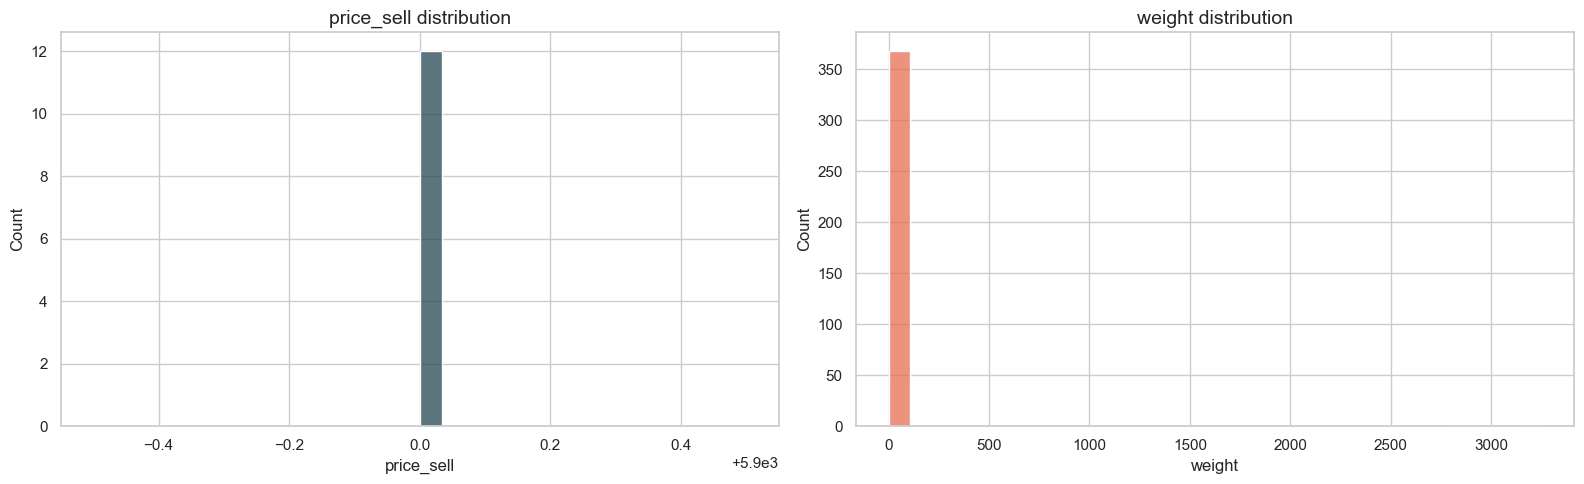

,non_null_ratio
age_zero_six_month,1.0
age_six_twelve_month,1.0
age_one_two_years,1.0
age_two_three_years,1.0
age_three_four_years,1.0
age_four_five_years,1.0
age_six_plus_years,1.0


In [24]:
product_cols = ['main_category', 'brand', 'color', 'weight', 'size', 'price_sell']
for col in product_cols:
    if col in new_products.columns:
        print(f'\n=== {col} ===')
        print(new_products[col].fillna('UNKNOWN').value_counts().head(10))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(pd.to_numeric(new_products['price_sell'], errors='coerce').dropna(), bins=30, ax=axes[0], color='#264653')
axes[0].set_title('price_sell distribution')
axes[0].set_xlabel('price_sell')

sns.histplot(pd.to_numeric(new_products['weight'], errors='coerce').dropna(), bins=30, ax=axes[1], color='#e76f51')
axes[1].set_title('weight distribution')
axes[1].set_xlabel('weight')
plt.tight_layout()
plt.show()

age_cols = [c for c in new_products.columns if c.startswith('age_')]
age_coverage = new_products[age_cols].notna().mean().sort_values(ascending=False)
display(age_coverage.to_frame('non_null_ratio'))

## 11. Kết luận EDA và bài học cho mô hình

Từ EDA, notebook sẽ tổng hợp 3 nhóm bài học chính: dữ liệu rất thưa và không đồng nhất giữa site cũ/new site, hành vi có tính chuỗi rõ rệt, và metadata sản phẩm đủ phong phú để dùng cho reranking hoặc content expansion.

Các bước tiếp theo nên làm:
- Làm sạch và chuẩn hóa kiểu dữ liệu cho các cột ngày, giá, danh mục.
- Tách session/user sequence rõ ràng hơn từ log lớn.
- Tạo feature cho chuỗi hành vi, co-occurrence, category transition, và repeated purchase.
- Ưu tiên mô hình hybrid thay vì một mô hình thuần CF/MF.